# DL Assignment 2: 
## Building a SimpleRNN Model for Weather Temperature Prediction
## By Gladwin Thomas
## DS09

## Part A – Data Understanding & Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

### 1. Load Dataset and Explore

In [2]:
df = pd.read_csv("weatherHistory.csv")

print(df.head(10))

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   
5  2006-04-01 05:00:00.000 +0200  Partly Cloudy        rain         9.222222   
6  2006-04-01 06:00:00.000 +0200  Partly Cloudy        rain         7.733333   
7  2006-04-01 07:00:00.000 +0200  Partly Cloudy        rain         8.772222   
8  2006-04-01 08:00:00.000 +0200  Partly Cloudy        rain        10.822222   
9  2006-04-01 09:00:00.000 +0200  Partly Cloudy        rain        13.772222   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   

### Convert Hourly Data into Daily Data

In [3]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

df["Date"] = df["Formatted Date"].dt.date

daily_df = df.groupby("Date").agg({
    "Temperature (C)": "mean",
    "Humidity": "mean",
    "Wind Speed (km/h)": "mean",
    "Pressure (millibars)": "mean"
}).reset_index()

daily_df.head()

,Date,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars)
0,2005-12-31,0.577778,0.890000,17.114300,1016.660000
1,2006-01-01,4.075000,0.817083,21.229192,1011.985000
2,2006-01-02,5.263194,0.847083,17.824713,1010.384167
3,2006-01-03,2.340509,0.897083,7.726658,1021.170833
4,2006-01-04,2.251852,0.906667,12.152817,981.770833


### Plot Temperature Trend Over Time

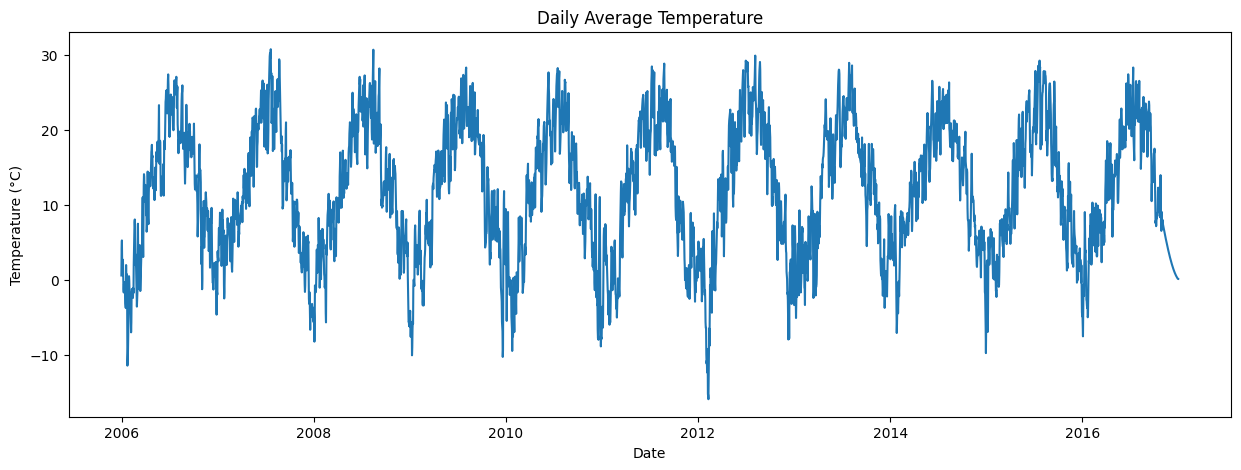

In [4]:
plt.figure(figsize=(15,5))
plt.plot(daily_df["Date"], daily_df["Temperature (C)"])
plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

### 2. Preprocess the data

### Missing Values

In [5]:
print(daily_df.isnull().sum())

Date                    0
Temperature (C)         0
Humidity                0
Wind Speed (km/h)       0
Pressure (millibars)    0
dtype: int64


### Handle Missing Values

In [6]:
daily_df.ffill(inplace=True)

### Select Features

In [7]:
features = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Pressure (millibars)"
]

target = "Temperature (C)"

## Normalize

In [8]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(daily_df[features])

## Create Sequences

In [9]:
sequence_length = 14

X = []
y = []

temperature_index = 0

for i in range(sequence_length, len(scaled)):
    X.append(scaled[i-sequence_length:i])
    y.append(scaled[i, temperature_index])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(4005, 14, 4)
(4005,)


## Train/Validation/Test Split

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    shuffle=False
)

## Part B - RNN Model Development

### 3. Build a SimpleRNN model using TensorFlow/Keras:

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input

I0000 00:00:1783309854.463983   13255 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Model

In [12]:
model = Sequential()

model = Sequential()

model.add(Input(shape=(sequence_length, len(features))))

model.add(SimpleRNN(
    64,
    activation='tanh'
))

model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

I0000 00:00:1783309857.260447   13255 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3119 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile the model:

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

### 5. Train the model on training data:

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=75,
    batch_size=32,
    verbose=1
)

Epoch 1/75


I0000 00:00:1783309861.048960   13313 service.cc:153] XLA service 0x651d952e6830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783309861.048980   13313 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1050, Compute Capability 6.1 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1783309861.111315   13313 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783309861.412451   13313 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1783309861.484579   13313 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_while_body_1171_grad_1404_const_0__.18.clone.clone.clone.clone.clone


22/88 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1409 - mae: 0.2955

I0000 00:00:1783309863.807088   13313 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


83/88 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0802 - mae: 0.2124

I0000 00:00:1783309864.829878   13311 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_while_body_1171_grad_1404_const_0__.18.clone.clone.clone.clone.clone


88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0412 - mae: 0.1519 - val_loss: 0.0052 - val_mae: 0.0559
Epoch 2/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0148 - mae: 0.0962 - val_loss: 0.0031 - val_mae: 0.0438
Epoch 3/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0108 - mae: 0.0826 - val_loss: 0.0028 - val_mae: 0.0411
Epoch 4/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0090 - mae: 0.0746 - val_loss: 0.0029 - val_mae: 0.0428
Epoch 5/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0077 - mae: 0.0696 - val_loss: 0.0025 - val_mae: 0.0397
Epoch 6/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0067 - mae: 0.0650 - val_loss: 0.0022 - val_mae: 0.0374
Epoch 7/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0065 - mae: 0.0636 - val_loss: 0.0021 - val_mae: 0.0364
Epoch 8/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0063 - mae: 0.0632 - val_loss: 0.0026 - val_mae: 0.0413
Epoch 9/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0061 - mae: 0

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0029 - mae: 0.0419 - val_loss: 0.0019 - val_mae: 0.0333
Epoch 56/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - mae: 0.0410 - val_loss: 0.0019 - val_mae: 0.0335
Epoch 57/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0027 - mae: 0.0412 - val_loss: 0.0019 - val_mae: 0.0340
Epoch 58/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0028 - mae: 0.0413 - val_loss: 0.0019 - val_mae: 0.0334
Epoch 59/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0409 - val_loss: 0.0021 - val_mae: 0.0355
Epoch 60/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0415 - val_loss: 0.0021 - val_mae: 0.0354
Epoch 61/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0028 - mae: 0.0416 - val_loss: 0.0019 - val_mae: 0.0333
Epoch 62/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0406 - val_loss: 0.0023 - val_mae: 0.0381
Epoch 63/75
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0026 - ma

### Loss Curve

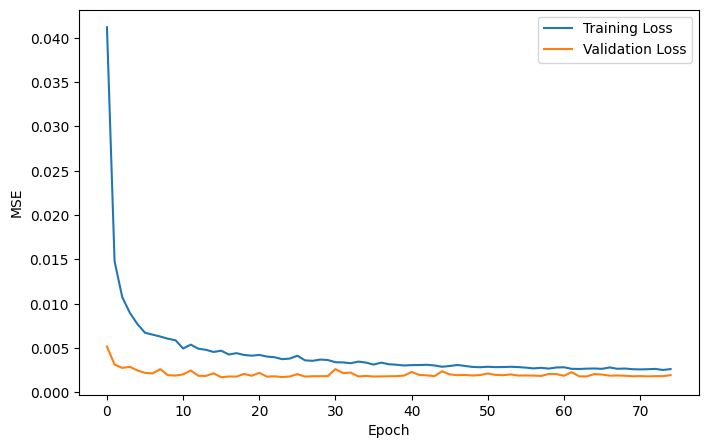

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

## Part C: Model Evaluation & Forecasting

### 6. Evaluate the model on the test set:

### Prediction

In [16]:
pred = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


### Convert Back to Temperature

Because only the temperature is predicted while the scaler was fit on three features, create dummy columns before inverse transforming.

In [17]:
dummy_pred = np.zeros((len(pred), len(features)))
dummy_true = np.zeros((len(y_test), len(features)))

dummy_pred[:,0] = pred.flatten()
dummy_true[:,0] = y_test

pred_temp = scaler.inverse_transform(dummy_pred)[:,0]
true_temp = scaler.inverse_transform(dummy_true)[:,0]

### Calculate RMSE, MAE, and R² score.

In [18]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(mean_squared_error(true_temp, pred_temp))
mae = mean_absolute_error(true_temp, pred_temp)
r2 = r2_score(true_temp, pred_temp)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

RMSE : 2.00715699974948
MAE  : 1.6210142521297344
R²   : 0.9438009355377466


### Plot predicted vs actual temperatures for the test period.

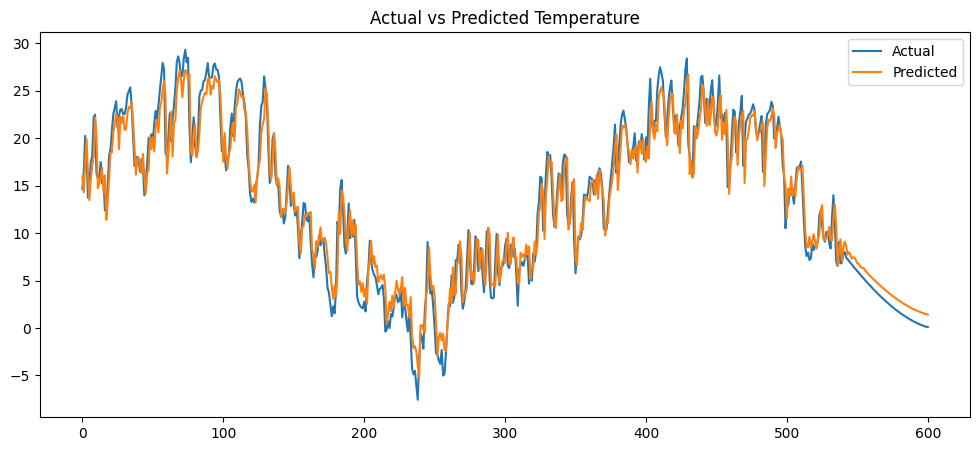

In [19]:
plt.figure(figsize=(12,5))

plt.plot(true_temp, label="Actual")
plt.plot(pred_temp, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()

### 7. Forecast the next 7 days of temperature using the trained model and visualize predictions vs recent historical data. 

In [20]:
last_sequence = scaled[-sequence_length:].copy()

future = []

for _ in range(7):

    prediction = model.predict(
        last_sequence.reshape(1, sequence_length, len(features)),
        verbose=0
    )[0][0]

    future.append(prediction)

    next_row = last_sequence[-1].copy()

    next_row[0] = prediction

    last_sequence = np.vstack([
        last_sequence[1:],
        next_row
    ])

In [21]:
print(prediction)

0.46708363


### Convert Forecast Back to Celsius

In [22]:
future_dummy = np.zeros((7, len(features)))
future_dummy[:,0] = future

future_temperature = scaler.inverse_transform(future_dummy)[:,0]

print(future_temperature)

[1.41085509 2.73514514 3.71208415 4.45982737 5.02345787 5.49112897
 5.88817567]


### Visualization

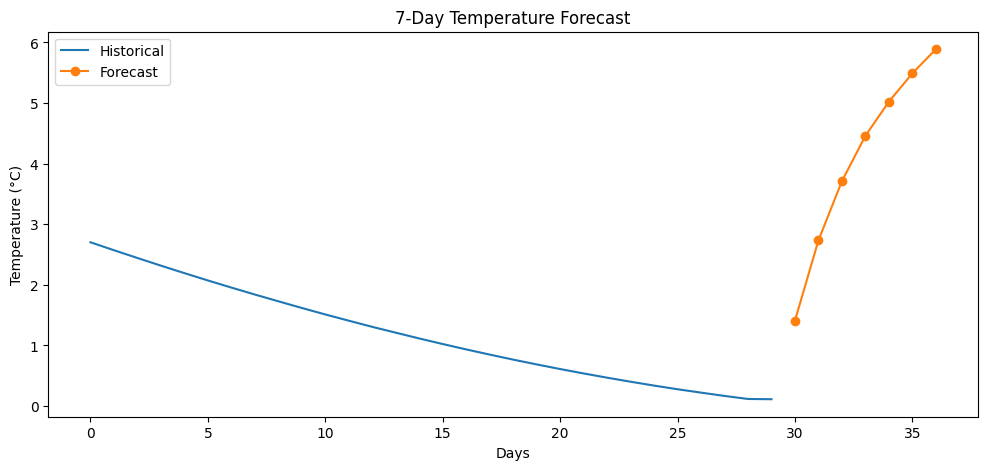

In [23]:
recent = daily_df["Temperature (C)"].tail(30).values

plt.figure(figsize=(12,5))

plt.plot(
    range(30),
    recent,
    label="Historical"
)

plt.plot(
    range(30,37),
    future_temperature,
    marker='o',
    label="Forecast"
)

plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("7-Day Temperature Forecast")
plt.show()